In [1]:
# Import the required packages

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf


In [2]:
# -----------------------------
# STEP 1: Define Stocks
# -----------------------------
stocks = [
    "HDFCBANK.NS", "ICICIBANK.NS", "SBIN.NS",
    "TCS.NS", "INFY.NS", "WIPRO.NS",
    "HINDUNILVR.NS", "ITC.NS", "NESTLEIND.NS",
    "SUNPHARMA.NS", "DRREDDY.NS", "CIPLA.NS",
    "RELIANCE.NS", "NTPC.NS", "ADANIPORTS.NS"
]


In [3]:
# -----------------------------
# STEP 2: Download Data
# -----------------------------
data = yf.download(stocks, start="2020-01-01", end="2025-01-01")['Close']


/tmp/ipykernel_1009/3928500119.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stocks, start="2020-01-01", end="2025-01-01")['Close']
[*********************100%***********************]  15 of 15 completed


In [4]:
# -----------------------------
# STEP 3: Calculate Returns
# -----------------------------
returns = data.pct_change().dropna()


In [5]:
# -----------------------------
# STEP 4: Mean Returns & Covariance
# -----------------------------
mean_returns = returns.mean()
cov_matrix = returns.cov()


In [6]:
# -----------------------------
# STEP 5: Portfolio Simulation
# -----------------------------
num_portfolios = 5000
results = np.zeros((3, num_portfolios))
weights_record = []

risk_free_rate = 0.05  # 5% (India approx)

for i in range(num_portfolios):
    weights = np.random.random(len(stocks))
    weights /= np.sum(weights)
    weights_record.append(weights)

    portfolio_return = np.sum(weights * mean_returns) * 252
    portfolio_std_dev = np.sqrt(np.dot(weights.T, np.dot(cov_matrix * 252, weights)))

    sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_std_dev

    results[0,i] = portfolio_return
    results[1,i] = portfolio_std_dev
    results[2,i] = sharpe_ratio


In [7]:
# -----------------------------
# STEP 6: Convert to DataFrame
# -----------------------------
results_df = pd.DataFrame(results.T, columns=['Return','Risk','Sharpe'])


In [8]:
# -----------------------------
# STEP 7: Identify Optimal Portfolios
# -----------------------------
max_sharpe_idx = results_df['Sharpe'].idxmax()
min_vol_idx = results_df['Risk'].idxmin()

max_sharpe_portfolio = results_df.loc[max_sharpe_idx]
min_vol_portfolio = results_df.loc[min_vol_idx]


In [9]:
# -----------------------------
# STEP 8: Print Results
# -----------------------------
print("\nMaximum Sharpe Ratio Portfolio:\n", max_sharpe_portfolio)
print("\nMinimum Variance Portfolio:\n", min_vol_portfolio)



Maximum Sharpe Ratio Portfolio:
 Return    0.247670
Risk      0.164612
Sharpe    1.200828
Name: 3997, dtype: float64

Minimum Variance Portfolio:
 Return    0.200209
Risk      0.156145
Sharpe    0.961984
Name: 3950, dtype: float64


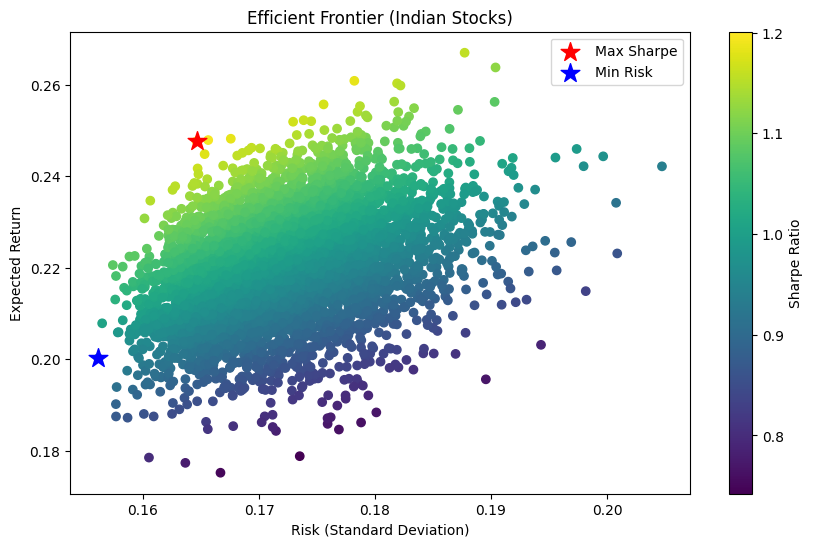

In [10]:
# -----------------------------
# STEP 9: Plot Efficient Frontier
# -----------------------------
plt.figure(figsize=(10,6))
plt.scatter(results_df['Risk'], results_df['Return'], c=results_df['Sharpe'], cmap='viridis')

plt.colorbar(label='Sharpe Ratio')
plt.scatter(max_sharpe_portfolio['Risk'], max_sharpe_portfolio['Return'], color='red', marker='*', s=200, label='Max Sharpe')
plt.scatter(min_vol_portfolio['Risk'], min_vol_portfolio['Return'], color='blue', marker='*', s=200, label='Min Risk')

plt.title('Efficient Frontier (Indian Stocks)')
plt.xlabel('Risk (Standard Deviation)')
plt.ylabel('Expected Return')
plt.legend()
plt.show()


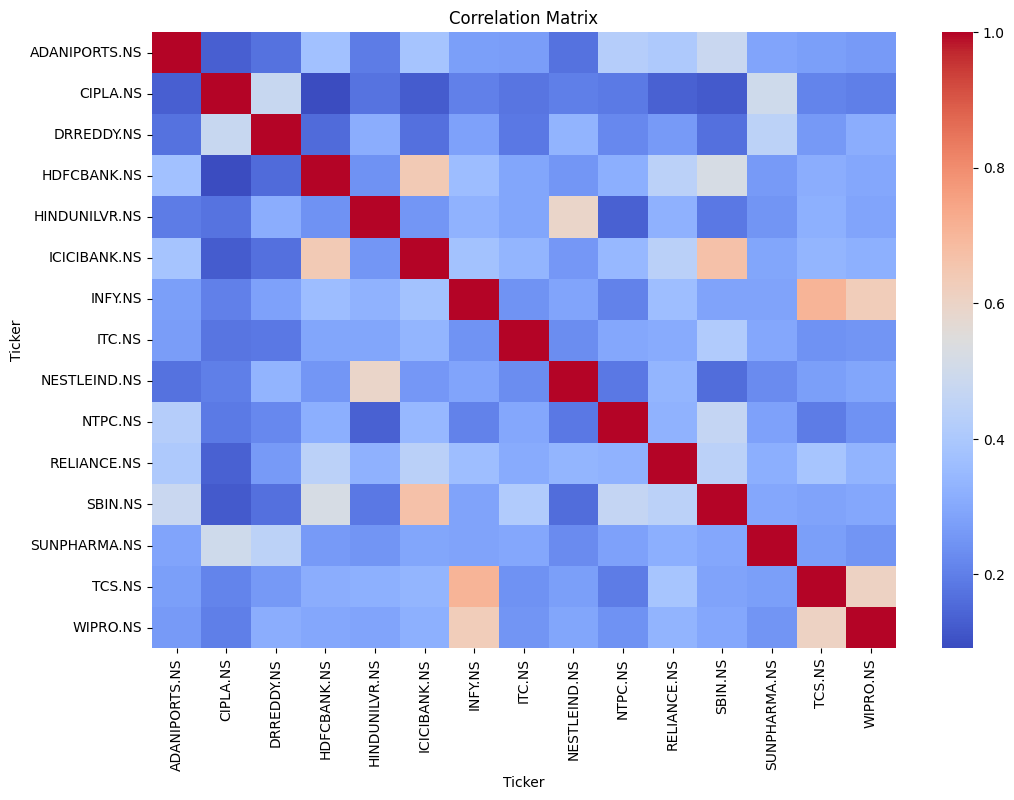

In [11]:
# -----------------------------
# STEP 10: Correlation Heatmap
# -----------------------------
plt.figure(figsize=(12,8))
sns.heatmap(returns.corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


In [12]:
# -----------------------------
# STEP 11: Show Weights of Best Portfolio
# -----------------------------
print("\nWeights of Maximum Sharpe Portfolio:\n")
for i, stock in enumerate(stocks):
    print(stock, ":", weights_record[max_sharpe_idx][i])



Weights of Maximum Sharpe Portfolio:

HDFCBANK.NS : 0.01684760598257393
ICICIBANK.NS : 0.13020912825972725
SBIN.NS : 0.05701458208147062
TCS.NS : 0.007130997164652968
INFY.NS : 0.021527600228751293
WIPRO.NS : 0.03757338524512659
HINDUNILVR.NS : 0.09606315740199542
ITC.NS : 0.13377128942377792
NESTLEIND.NS : 0.040102234068257865
SUNPHARMA.NS : 0.11696212583869958
DRREDDY.NS : 0.048355125635415816
CIPLA.NS : 0.0139179561202876
RELIANCE.NS : 0.13373135667751648
NTPC.NS : 0.05078819429792296
ADANIPORTS.NS : 0.09600526157382368
